<a href="https://colab.research.google.com/github/Praj24-04/Machine-Learning/blob/main/MLPrac9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**IMPORT LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

#**LOAD THE DATASET**

In [ ]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.columns)
# Display first 5 rows
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

#**DATA PRE PROESSING**

In [ ]:
df['Gender'] = df['Genre'].map({'Male': 0, 'Female': 1})
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#**REMOVE OUTLIERS USING IQR**

In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X_clean = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Before:", X.shape)
print("After:", X_clean.shape)

Before: (200, 2)
After: (198, 2)


#**FEATURE SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

#**TRAIN-TEST-SPLIT**

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

#**ELBOW METHOD**

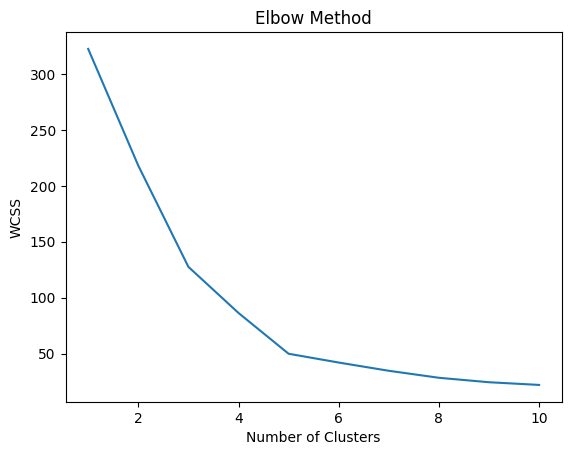

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

#**APPLYING K-MEANS CLUSTERING**

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_train)

#**HIRARCHICAL CLUTERING**

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_train)

#**VISUALIZATION**

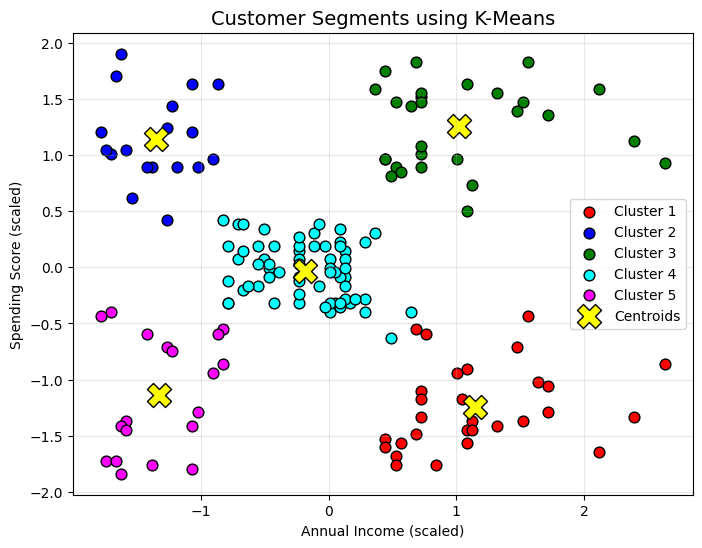

In [ ]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X_train[y_kmeans == i, 0],
        X_train[y_kmeans == i, 1],
        color=colors[i],
        s=60,
        edgecolor='black',
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='yellow',
    s=300,
    marker='X',
    edgecolor='black',
    label='Centroids'
)

plt.title('Customer Segments using K-Means', fontsize=14)
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#**MODEL EVALUATION USING SILHOUETTE SCORE**

In [ ]:
kmeans_score = silhouette_score(X_train, y_kmeans)
hc_score = silhouette_score(X_train, y_hc)

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Clustering Silhouette Score:", hc_score)

K-Means Silhouette Score: 0.5586469871484757
Hierarchical Clustering Silhouette Score: 0.5557393913698884
